# Visual-TCAV on FlexibleTNet (Circle Detection)

This notebook applies the **Visual-TCAV** method to interpret the `flex_circle_only` model
(a FlexibleTNet trained for binary circle detection on AIXI-Shape images).

We use **Captum** utilities where possible to simplify the implementation:
- `LayerActivation` for extracting intermediate feature maps
- `LayerIntegratedGradients` for layer-level integrated gradients
- `Concept` / `CustomIterableDataset` for concept data management

The Visual-TCAV-specific logic (centroid-based CAVs, concept maps, concept emblems,
masked attributions) is implemented on top of these Captum primitives.

---

## 1. Setup and Model Loading

In [1]:
import sys, os, csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm as mpl_cm
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from pathlib import Path
from tqdm import tqdm
from itertools import combinations

import torch
import torch.nn.functional as F
from PIL import Image, ImageFilter
from torchvision import transforms

# Captum
from captum.attr import LayerActivation, LayerIntegratedGradients
from captum.concept import Concept
from captum.concept._utils.data_iterator import dataset_to_dataloader, CustomIterableDataset

# Project root
PROJECT_ROOT = Path(os.path.abspath('')).parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from model.model_dylan import FlexibleTNet

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")

Project root: /home/dylan-canning/Documents/Testing-with-Concept-Activation-Vectors/Testing-with-Concept-Activation-Vectors
Device: cpu


/home/dylan-canning/Documents/Testing-with-Concept-Activation-Vectors/Testing-with-Concept-Activation-Vectors/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load FlexibleTNet
WEIGHTS_PATH = PROJECT_ROOT / "weights" / "flex_circle_only.pt"

model = FlexibleTNet(
    num_channels=1, num_classes=1,
    conv_channels=[8], fc_layers=[32],
    dropout_p=0.2, do_sigmoid=True, size_img=128,
)
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE, weights_only=True))
model.to(DEVICE).eval()

print(f"Model loaded from {WEIGHTS_PATH}")
print(model)

Model loaded from /home/dylan-canning/Documents/Testing-with-Concept-Activation-Vectors/Testing-with-Concept-Activation-Vectors/weights/flex_circle_only.pt
FlexibleTNet(
  (conv_layers): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (1): ReLU()
      (2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (fc_layers): Sequential(
    (0): Sequential(
      (0): Linear(in_features=32768, out_features=32, bias=True)
      (1): Dropout(p=0.2, inplace=False)
      (2): ReLU()
    )
  )
  (output): Linear(in_features=32, out_features=1, bias=True)
  (final_act): Sigmoid()
)


## 2. Concept Assembly (Captum)

We use Captum's `Concept` and `CustomIterableDataset` to manage concept images,
matching the pattern from `experiment_1.ipynb`.

In [3]:
IMG_SIZE = 128
CONCEPTS_DIR = PROJECT_ROOT / "data" / "concepts"

img_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


def get_tensor_from_filename(filename):
    img = Image.open(filename).convert("L")
    return img_transform(img).to(DEVICE).float()


def assemble_concept(name, cid, concepts_path=CONCEPTS_DIR):
    concept_path = str(concepts_path / name) + "/"
    dataset = CustomIterableDataset(get_tensor_from_filename, concept_path)
    concept_iter = dataset_to_dataloader(dataset)
    return Concept(id=cid, name=name, data_iter=concept_iter)


# Geometric concepts
circle_full = assemble_concept("circle_full", 0)
cross_full  = assemble_concept("cross_full",  1)
square_full = assemble_concept("square_full", 2)

# Random pool (negative examples for CAV)
random_pool = assemble_concept("random_pool_4", 100)

CONCEPTS = [circle_full, cross_full, square_full]
print(f"Concepts: {[c.name for c in CONCEPTS]}")
print(f"Random pool: {random_pool.name}")

Concepts: ['circle_full', 'cross_full', 'square_full']
Random pool: random_pool_4


## 3. Visual-TCAV Core (Captum + custom)

**Captum handles:**
- `LayerActivation` — extract feature maps at any layer (replaces manual hooks)
- `LayerIntegratedGradients` — layer-level IG (replaces manual interpolation + backward)

**Visual-TCAV-specific (custom):**
- Centroid-based CAV direction
- Concept emblems (contraharmonic mean normalization)
- Spatial concept maps
- Masked concept attributions

In [4]:
def collect_concept_activations(model, layer, concept, max_imgs=500):
    """
    Use Captum's LayerActivation to extract feature maps for a concept's images.
    Returns: Tensor [N, C, H, W]
    """
    layer_act = LayerActivation(model, layer)
    all_acts = []
    count = 0
    for batch in concept.data_iter:
        if count >= max_imgs:
            break
        batch = batch.to(DEVICE)
        acts = layer_act.attribute(batch)
        all_acts.append(acts.detach())
        count += len(batch)
    return torch.cat(all_acts, dim=0)[:max_imgs]


def contraharmonic_mean(arr, dim=(2, 3)):
    """Contraharmonic mean (from VisualTCAV.py)."""
    return torch.sum(arr ** 2, dim=dim) / (torch.sum(arr, dim=dim) + 1e-7)


def compute_cav(concept_fmaps, random_fmaps):
    """
    Centroid-based CAV direction + concept emblem for normalization.
    Returns: (direction [C], concept_emblem (pos_median, neg_median))
    """
    centroid_c = concept_fmaps.mean(dim=(0, 2, 3))  # [C]
    centroid_r = random_fmaps.mean(dim=(0, 2, 3))   # [C]
    direction = centroid_c - centroid_r

    proj_c = F.relu((direction[None, :, None, None] * concept_fmaps).sum(dim=1))
    proj_r = F.relu((direction[None, :, None, None] * random_fmaps).sum(dim=1))

    emblem = (
        torch.quantile(contraharmonic_mean(proj_c, dim=(1, 2)), 0.5).item(),
        torch.quantile(contraharmonic_mean(proj_r, dim=(1, 2)), 0.5).item(),
    )
    return direction, emblem


def compute_concept_map(feature_maps, cav_direction, emblem):
    """Spatial concept map for a single image. Returns [H, W] in [0, 1]."""
    cmap = F.relu((cav_direction[:, None, None] * feature_maps).sum(dim=0))
    if emblem[0] > emblem[1]:
        cmap = torch.clamp(cmap, min=emblem[1], max=emblem[0])
        cmap = (cmap - emblem[1]) / (emblem[0] - emblem[1])
    else:
        cmap = cmap * 0
    return cmap


def compute_concept_attribution(model, layer, input_tensor, cav_direction, emblem, m_steps=50):
    """
    Full Visual-TCAV concept attribution for one image (binary classification).
    Uses Captum's LayerActivation + LayerIntegratedGradients.

    Returns: (attributions {0: float, 1: float}, concept_map [H, W])
    """
    inp = input_tensor.unsqueeze(0).to(DEVICE)

    # Feature maps via Captum LayerActivation
    fmaps = LayerActivation(model, layer).attribute(inp)[0]  # [C, H, W]

    # Concept map
    concept_map = compute_concept_map(fmaps, cav_direction, emblem)

    # Integrated gradients via Captum LayerIntegratedGradients
    ig = LayerIntegratedGradients(model, layer).attribute(
        inp, n_steps=m_steps, target=0,
    )[0]  # [C, H, W]

    # Binary attributions (VisualTCAV logic)
    binary_attr = ig * fmaps
    vl_pos = F.relu(binary_attr).sum()
    vl_neg = F.relu(-binary_attr).sum()
    max_vl = max(vl_pos.item(), vl_neg.item())
    if max_vl > 0:
        vl_pos, vl_neg = vl_pos / max_vl, vl_neg / max_vl

    attr_pos = F.relu(binary_attr) / (F.relu(binary_attr).sum() + 1e-7) * vl_pos
    attr_neg = F.relu(-binary_attr) / (F.relu(-binary_attr).sum() + 1e-7) * vl_neg

    # Masked attributions per class
    attributions = {}
    for n_class, attr in enumerate([attr_pos, attr_neg]):
        pooled_masked = (attr * concept_map[None, :, :]).sum(dim=(1, 2))

        if fmaps.min() < 0:
            sign = torch.where(
                (fmaps * concept_map[None, :, :]).sum(dim=(1, 2)) < 0, -1.0, 1.0
            )
            pooled_cav = F.relu(cav_direction * sign)
        else:
            pooled_cav = F.relu(cav_direction)

        if pooled_cav.max() > 0:
            pooled_cav = pooled_cav / pooled_cav.max()

        attributions[n_class] = torch.dot(pooled_cav, pooled_masked).item()

    return attributions, concept_map


print("Visual-TCAV core functions defined (using Captum).")

Visual-TCAV core functions defined (using Captum).


## 4. Visualization

In [5]:
# Custom colormap (same as VisualTCAV.py)
_base = mpl_cm.jet
_nodes = [0.0, 0.05] + list(np.linspace(0.1, 1.0, 100))
_colors = [(0,0,0,1), (0,0,0,1)] + [_base(i) for i in np.linspace(0.15, 1.0, 100)]
VTCAV_CMAP = LinearSegmentedColormap.from_list("vtcav", list(zip(_nodes, _colors)))


def plot_local_explanation(img_np, concept_results, layer_names, class_names):
    """Plot Visual-TCAV heatmaps + attribution tables per concept."""
    n_layers = len(layer_names)

    for concept_name, layers_data in concept_results.items():
        fig = plt.figure(figsize=(4 + 4 * (n_layers - 1), 7))
        gs = GridSpec(3, n_layers * 3, height_ratios=[2, 5, 0.5])
        fig.suptitle(f"Concept: {concept_name}", fontsize=14, fontweight='bold')

        for j, layer_name in enumerate(layer_names):
            data = layers_data[layer_name]
            cmap_np = data['concept_map'].cpu().numpy()
            attribs = data['attributions']

            h, w = img_np.shape[:2]
            heatmap = np.array(
                Image.fromarray((cmap_np * 255).astype(np.uint8), 'L')
                .resize((w, h), Image.BILINEAR)
                .filter(ImageFilter.GaussianBlur(radius=10))
            ) / 255.0
            max_val = cmap_np.max()
            if heatmap.max() > 0 and heatmap.max() < max_val:
                heatmap = (heatmap / heatmap.max()) * max_val

            # Heatmap
            ax = fig.add_subplot(gs[1, j*3:(j+1)*3])
            ax.imshow(img_np, cmap='gray')
            ax.imshow(heatmap, cmap=VTCAV_CMAP, alpha=0.6, vmin=0, vmax=1)
            ax.axis('off')

            # Table
            ax_t = fig.add_subplot(gs[0, j*3:(j+1)*3])
            short = layer_name.split('.')[-1] if '.' in layer_name else layer_name
            ax_t.set_title(short, fontsize=11, fontweight='bold', pad=8)
            rows = [[class_names[c], f"{v:.2g}" if v >= 0.001 or v == 0 else f"{v:.1e}"]
                    for c, v in sorted(attribs.items())]
            tbl = ax_t.table(cellText=rows, colLabels=["Class", "Attrib."],
                             cellLoc='center', loc='center', edges='BRTL')
            tbl.auto_set_font_size(False)
            tbl.set_fontsize(10)
            for k, cell in tbl.get_celld().items():
                if k[0] == 0: cell.set_facecolor('silver')
            ax_t.axis('off')

        fig.tight_layout()
        plt.show()


print("Visualization ready.")

Visualization ready.


---

## 5. Local Explainer

### 5.1 Pick test images and predict

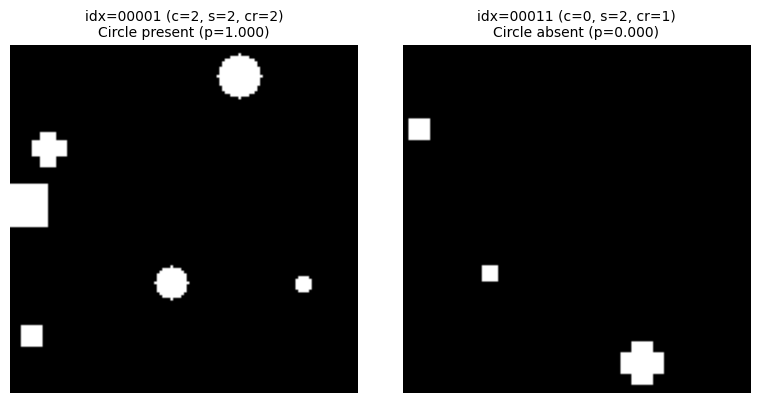

In [6]:
val_csv = PROJECT_ROOT / "data" / "aixi_shape" / "val" / "dades.csv"
val_dir = PROJECT_ROOT / "data" / "aixi_shape" / "val"

with open(val_csv) as f:
    rows = list(csv.DictReader(f, delimiter=";"))

# Find one image with circles and one without
img_with, img_without = None, None
for r in rows:
    idx, c, s, cr = int(r[""]), int(r["c"]), int(r["s"]), int(r["cr"])
    if c > 0 and s > 0 and img_with is None:
        img_with = (idx, c, s, cr)
    if c == 0 and s > 0 and img_without is None:
        img_without = (idx, c, s, cr)
    if img_with and img_without:
        break

# Show both
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (idx, c, s, cr) in zip(axes, [img_with, img_without]):
    img = Image.open(val_dir / f"{idx:05d}.png")
    t = img_transform(img.convert("L")).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        p = model(t).item()
    ax.imshow(np.array(img), cmap='gray')
    label = "Circle present" if p > 0.5 else "Circle absent"
    ax.set_title(f"idx={idx:05d} (c={c}, s={s}, cr={cr})\n{label} (p={p:.3f})", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

### 5.2 Compute CAVs

Extract activations at `conv_layers.0` using Captum's `LayerActivation`,
then compute centroid-based CAV directions.

In [7]:
LAYER = model.conv_layers[0]   # the nn.Sequential conv block
LAYER_NAME = "conv_layers.0"
MAX_EXAMPLES = 500

# Extract activations for random pool
print("Extracting random activations...")
random_fmaps = collect_concept_activations(model, LAYER, random_pool, MAX_EXAMPLES)
print(f"  shape: {random_fmaps.shape}")

# Compute CAVs for each concept
cavs = {}
for concept in CONCEPTS:
    print(f"Computing CAV for '{concept.name}'...")
    concept_fmaps = collect_concept_activations(model, LAYER, concept, MAX_EXAMPLES)
    direction, emblem = compute_cav(concept_fmaps, random_fmaps)
    cavs[concept.name] = {'direction': direction, 'emblem': emblem}
    print(f"  norm={direction.norm():.4f}, emblem=({emblem[0]:.4f}, {emblem[1]:.4f})")

Extracting random activations...


  shape: torch.Size([500, 8, 64, 64])
Computing CAV for 'circle_full'...
  norm=1.4508, emblem=(4.1298, 0.0048)
Computing CAV for 'cross_full'...
  norm=1.4809, emblem=(0.1438, 0.0383)
Computing CAV for 'square_full'...
  norm=1.3746, emblem=(0.1363, 0.0375)


### 5.3 Local explanation — image with circles

  circle_full: circle=0.7702, no_circle=0.01497
  cross_full: circle=5.852e-05, no_circle=0.0002529
  square_full: circle=2.015e-05, no_circle=4.6e-05


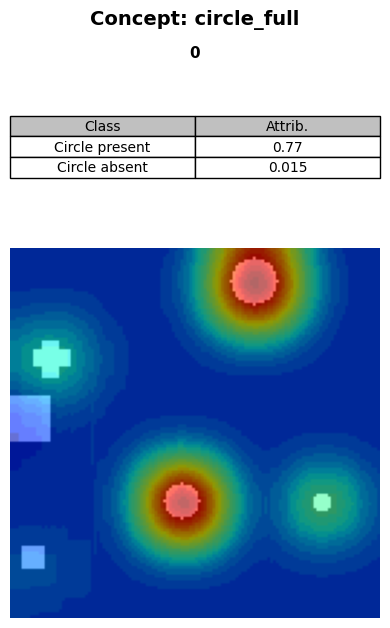

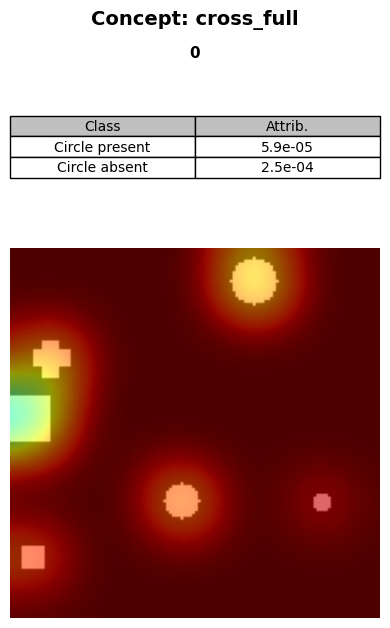

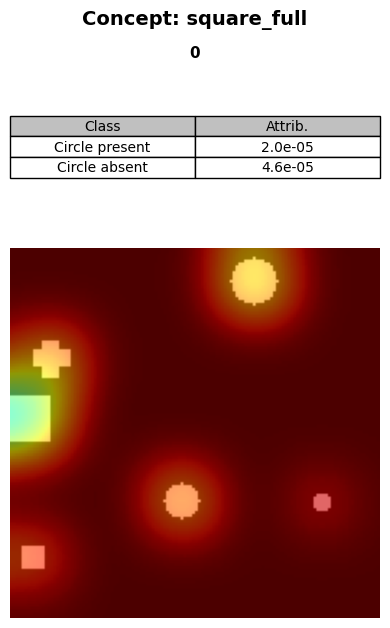

In [8]:
test_path = val_dir / f"{img_with[0]:05d}.png"
test_pil = Image.open(test_path).convert("L")
test_tensor = img_transform(test_pil)

class_names = {0: "Circle present", 1: "Circle absent"}

concept_results = {}
for concept in CONCEPTS:
    cav = cavs[concept.name]
    attribs, cmap = compute_concept_attribution(
        model, LAYER, test_tensor, cav['direction'], cav['emblem'], m_steps=50
    )
    concept_results[concept.name] = {
        LAYER_NAME: {'concept_map': cmap, 'attributions': attribs}
    }
    print(f"  {concept.name}: circle={attribs[0]:.4g}, no_circle={attribs[1]:.4g}")

plot_local_explanation(np.array(test_pil), concept_results, [LAYER_NAME], class_names)

### 5.4 Local explanation — image without circles

  circle_full: circle=0.3381, no_circle=0.09368
  cross_full: circle=0.0007456, no_circle=2.44e-06
  square_full: circle=6.071e-05, no_circle=3.303e-07


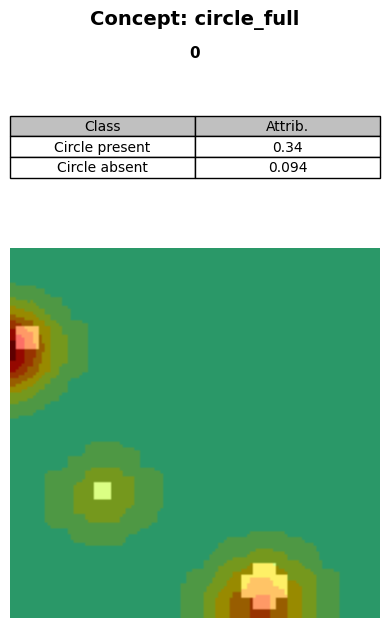

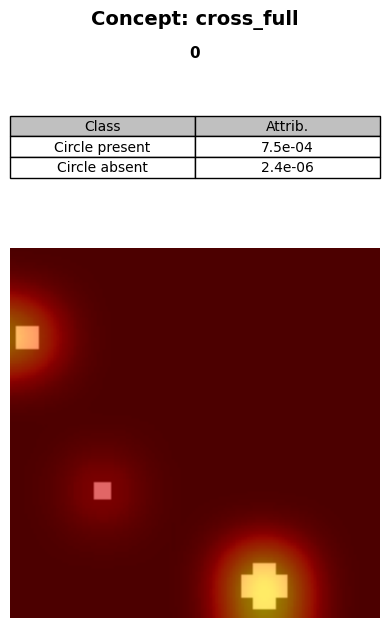

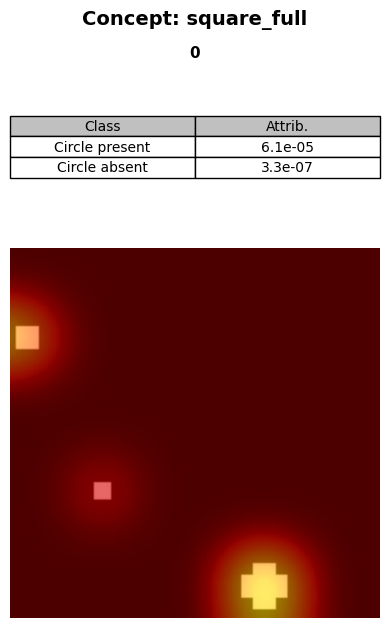

In [9]:
test_path2 = val_dir / f"{img_without[0]:05d}.png"
test_pil2 = Image.open(test_path2).convert("L")
test_tensor2 = img_transform(test_pil2)

concept_results2 = {}
for concept in CONCEPTS:
    cav = cavs[concept.name]
    attribs, cmap = compute_concept_attribution(
        model, LAYER, test_tensor2, cav['direction'], cav['emblem'], m_steps=50
    )
    concept_results2[concept.name] = {
        LAYER_NAME: {'concept_map': cmap, 'attributions': attribs}
    }
    print(f"  {concept.name}: circle={attribs[0]:.4g}, no_circle={attribs[1]:.4g}")

plot_local_explanation(np.array(test_pil2), concept_results2, [LAYER_NAME], class_names)

---

## 6. Global Explainer

Aggregate concept attributions across multiple validation images.

In [10]:
# Select 50 images per group
circle_indices, no_circle_indices = [], []
for r in rows:
    idx, c = int(r[""]), int(r["c"])
    if c > 0 and len(circle_indices) < 50:
        circle_indices.append(idx)
    elif c == 0 and len(no_circle_indices) < 50:
        no_circle_indices.append(idx)

print(f"Circle present: {len(circle_indices)} images")
print(f"Circle absent:  {len(no_circle_indices)} images")

Circle present: 50 images
Circle absent:  50 images


In [11]:
def run_global_explanation(model, layer, indices, val_dir, cavs, concepts, m_steps=50):
    """Compute per-concept attributions (class 0) for a list of images."""
    results = {c.name: [] for c in concepts}
    for idx in tqdm(indices, desc="Images"):
        t = img_transform(Image.open(val_dir / f"{idx:05d}.png").convert("L"))
        for concept in concepts:
            cav = cavs[concept.name]
            attribs, _ = compute_concept_attribution(
                model, layer, t, cav['direction'], cav['emblem'], m_steps
            )
            results[concept.name].append(attribs[0])
    return results


print("Running global explanation \u2014 circle present...")
global_circle = run_global_explanation(model, LAYER, circle_indices, val_dir, cavs, CONCEPTS)

print("Running global explanation \u2014 circle absent...")
global_no_circle = run_global_explanation(model, LAYER, no_circle_indices, val_dir, cavs, CONCEPTS)

Running global explanation — circle present...


Images: 100%|██████████| 50/50 [00:03<00:00, 13.25it/s]


Running global explanation — circle absent...


Images: 100%|██████████| 50/50 [00:03<00:00, 13.12it/s]


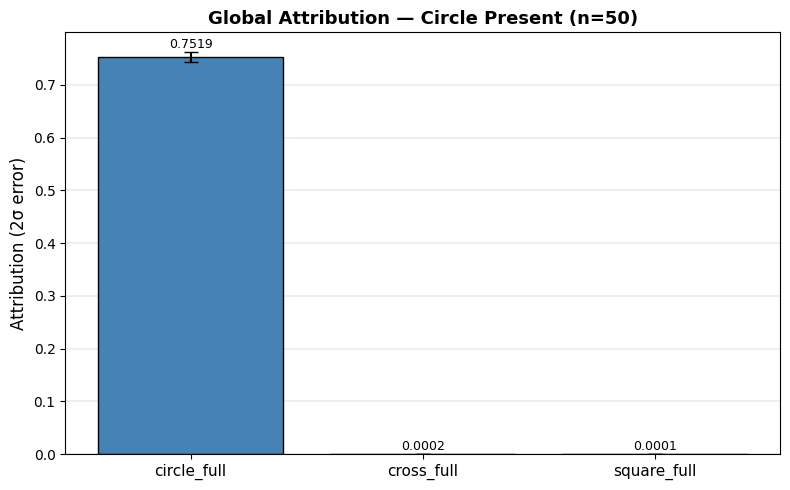

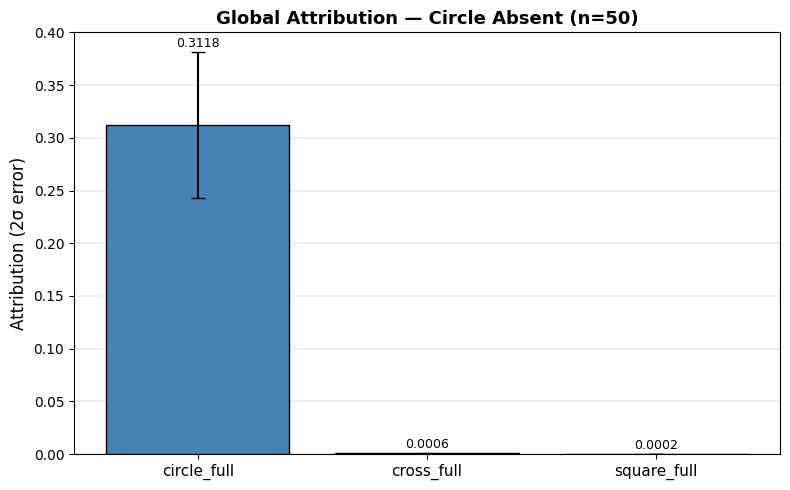

In [12]:
def plot_global_results(attrib_dict, title, concepts):
    names = [c.name for c in concepts]
    means = [np.mean(attrib_dict[n]) for n in names]
    errs  = [2 * np.std(attrib_dict[n]) / np.sqrt(len(attrib_dict[n])) for n in names]

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(names))
    ax.bar(x, means, yerr=errs, capsize=5, color='steelblue', edgecolor='black', zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=11)
    ax.set_ylabel("Attribution (2\u03c3 error)", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(axis='y', linewidth=0.3, zorder=1)
    ax.set_ylim(bottom=0)
    for i, (m, e) in enumerate(zip(means, errs)):
        ax.text(i, m + e + 0.002, f"{m:.4f}", ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()


plot_global_results(global_circle, f"Global Attribution \u2014 Circle Present (n={len(circle_indices)})", CONCEPTS)
plot_global_results(global_no_circle, f"Global Attribution \u2014 Circle Absent (n={len(no_circle_indices)})", CONCEPTS)

### 6.1 Statistical summary

In [13]:
for group_name, attrib_dict in [("Circle Present", global_circle),
                                 ("Circle Absent", global_no_circle)]:
    print(f"{'=' * 72}")
    print(f"  FlexibleTNet \u2014 {group_name}")
    print(f"{'=' * 72}")
    print(f"{'Concept':<15} {'Layer':<18} {'Mean \u00b1 Std':<20} {'95.45% CI'}")
    print("-" * 65)
    for c in CONCEPTS:
        vals = np.array(attrib_dict[c.name])
        m, s = vals.mean(), vals.std()
        se = s / np.sqrt(len(vals))
        print(f"{c.name:<15} {LAYER_NAME:<18} {m:.4g} \u00b1 {s:.4g}{'':>5} [{max(0, m-2*se):.4g}, {m+2*se:.4g}]")
    print()

  FlexibleTNet — Circle Present
Concept         Layer              Mean ± Std           95.45% CI
-----------------------------------------------------------------
circle_full     conv_layers.0      0.7519 ± 0.0334      [0.7424, 0.7613]
cross_full      conv_layers.0      0.0002345 ± 0.0001573      [0.0001901, 0.000279]
square_full     conv_layers.0      5.731e-05 ± 5.794e-05      [4.092e-05, 7.37e-05]

  FlexibleTNet — Circle Absent
Concept         Layer              Mean ± Std           95.45% CI
-----------------------------------------------------------------
circle_full     conv_layers.0      0.3118 ± 0.2447      [0.2426, 0.381]
cross_full      conv_layers.0      0.0006354 ± 0.0009951      [0.0003539, 0.0009168]
square_full     conv_layers.0      0.0001825 ± 0.0003729      [7.706e-05, 0.000288]



---

## 7. CAV Direction Analysis

Cosine similarities between CAV directions:
  circle_full vs cross_full: 0.9785
  circle_full vs square_full: 0.9722
  cross_full vs square_full: 0.9994


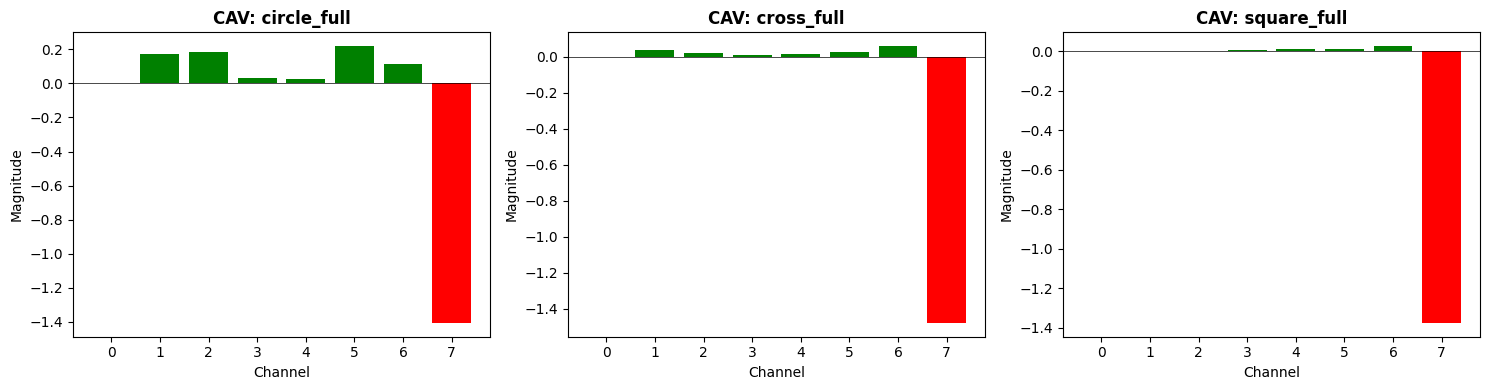

In [14]:
concept_names = [c.name for c in CONCEPTS]

print("Cosine similarities between CAV directions:")
for a, b in combinations(concept_names, 2):
    cos = F.cosine_similarity(
        cavs[a]['direction'].unsqueeze(0),
        cavs[b]['direction'].unsqueeze(0)
    ).item()
    print(f"  {a} vs {b}: {cos:.4f}")

# Per-channel direction bars
fig, axes = plt.subplots(1, len(CONCEPTS), figsize=(5 * len(CONCEPTS), 4))
for ax, name in zip(axes, concept_names):
    d = cavs[name]['direction'].cpu().numpy()
    ax.bar(range(len(d)), d, color=['green' if v > 0 else 'red' for v in d])
    ax.set_title(f"CAV: {name}", fontweight='bold')
    ax.set_xlabel("Channel")
    ax.set_ylabel("Magnitude")
    ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

---

## 8. Summary

### What Captum simplified

| Component | Before (manual) | After (Captum) |
|-----------|------------------|-----------------|
| Feature map extraction | Manual forward hooks | `LayerActivation.attribute()` |
| Integrated gradients | Manual interpolation + backward loop | `LayerIntegratedGradients.attribute()` |
| Concept data loading | Custom `load_concept_images()` | `Concept` + `CustomIterableDataset` |

### What remains Visual-TCAV-specific

- Centroid-based CAV direction (vs Captum's classifier-based)
- Concept emblems (contraharmonic mean normalization)
- Spatial concept maps
- Masked concept attributions with normalized CAV weighting